In [4]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm

In [5]:
# ==========================================
# 1. CUSTOM LOSS FUNCTIONS
# ==========================================
class FocalLoss(nn.Module):
    """Class Balanced Focal Loss for Severity Grading (Head B)"""
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [6]:
# ==========================================
# 2. MULTI-SCALE RESNET ARCHITECTURE
# ==========================================
class MultiScaleDRNet(nn.Module):
    def __init__(self):
        super(MultiScaleDRNet, self).__init__()
        print("Initializing Custom Multi-Scale ResNet-50 Backbone...")
        
        # Base ResNet-50
        resnet = models.resnet50(weights=None)
        resnet.load_state_dict(torch.load('resnet50-11ad3fa6.pth', map_location='cpu'))        
        # Stem (Input -> 128x128)
        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )
        
        # Encoders
        self.layer1 = resnet.layer1  # Low-Res Fine Detail [256 channels, 128x128]
        self.layer2 = resnet.layer2  # [512 channels, 64x64]
        self.layer3 = resnet.layer3  # [1024 channels, 32x32]
        self.layer4 = resnet.layer4  # Deep Semantic [2048 channels, 16x16]
        
        # Early Feature Compression (from Layer 1) -> Target: 512 x 16 x 16
        self.early_compression = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.AdaptiveAvgPool2d((16, 16))
        )
        
        # Deep Feature Compression (from Layer 4) -> Target: 512 x 16 x 16
        self.deep_compression = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512)
        )
        
        # Global Pooling before Heads
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Task-Specific Heads
        self.head_a_lesion = nn.Linear(512, 7)  # Multi-label Lesion Mask
        self.head_b_grade = nn.Linear(512, 5)   # DR Severity Grading

    def forward(self, x):
        # Image input: 512x512
        x = self.stem(x)
        
        # Forward through layers
        l1 = self.layer1(x)  # Fine details extracted here
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3) # Global context extracted here
        
        # Compress Features
        early_feat = self.early_compression(l1)
        deep_feat = self.deep_compression(l4)
        
        # Element-wise Fusion & ReLU
        fused_features = F.relu(early_feat + deep_feat)
        
        # Pool to 1D vector (Batch x 512)
        pooled = self.global_pool(fused_features).flatten(1)
        
        # Route to heads
        lesion_logits = self.head_a_lesion(pooled)
        grade_logits = self.head_b_grade(pooled)
        
        return grade_logits, lesion_logits

In [7]:

# ==========================================
# 3. DATASET MANAGEMENT
# ==========================================
class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(self.img_dir, str(row['image']))
        if img_path is None or not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, str(row['image']))
            
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback canvas ensures loader never crashes
            image = Image.new('RGB', (512, 512), (0, 0, 0))
        
        image = apply_circular_mask(image)
        
        if self.transform:
            image = self.transform(image)
            
        grade_label = int(row['grade'])
        
        # Robust string parser for '[1, 0, 0, 1...]' formats
        lesion_str = str(row['lesion']).strip()
        if lesion_str.startswith('[') and lesion_str.endswith(']'):
            lesion_str = lesion_str[1:-1]
        
        try:
            lesion_labels = np.array([float(x.strip()) for x in lesion_str.split(',') if x.strip() != ''], dtype=np.float32)
            if len(lesion_labels) != 7:
                raise ValueError
        except ValueError:
            lesion_labels = np.zeros(7, dtype=np.float32)
                
        return image, grade_label, lesion_labels

def resolve_data_dir(base_path):
    if os.path.isabs(base_path):
        return base_path
    return os.path.normpath(os.path.join(os.path.dirname(__file__), base_path))

def execute_mmrdr_split(base_path, modality):
    data_dir = resolve_data_dir(base_path)
    modality_label = 'FP' if modality.lower() == 'cfp' else modality.upper()
    file_path = os.path.join(data_dir, f'MMRDR-{modality.upper()}', f'{modality_label}.csv')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: Metadata sheet not found at {file_path}")
        
    df = pd.read_csv(file_path)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    return train_df, test_df

def apply_circular_mask(pil_img, tightness=0.96):
    img = np.array(pil_img)
    gray = np.mean(img, axis=2)
    thresh = gray > 10 

    if not np.any(thresh):
        return pil_img

    nonzero_coords = np.argwhere(thresh)
    ymin, xmin = nonzero_coords.min(axis=0)
    ymax, xmax = nonzero_coords.max(axis=0)

    img_cropped = img[ymin : ymax + 1, xmin : xmax + 1]
    h, w, _ = img_cropped.shape
    center_y, center_x = h // 2, w // 2
    radius = int(min(center_y, center_x) * tightness)

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    mask = dist <= radius

    clean_img = np.zeros_like(img_cropped)
    clean_img[mask] = img_cropped[mask]

    return Image.fromarray(clean_img)

def resolve_image_path(img_root, image_field):
    image_field = str(image_field).strip().replace("\\", "/")
    image_field = image_field.lstrip("./")

    candidates = [
        os.path.join(img_root, image_field),
        os.path.join(img_root, os.path.basename(image_field)),
        os.path.join(img_root, "img", os.path.basename(image_field)),
        os.path.join(img_root, "img", image_field),
    ]

    seen = set()
    unique_candidates = []
    for c in candidates:
        c = os.path.normpath(c)
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)

    for path in unique_candidates:
        if os.path.exists(path):
            return path
    return None



In [5]:
# ==========================================
# 4. TRAINING ENGINE PIPELINE
# ==========================================
def main():
    data_dir = os.path.abspath("MMRDR")
    modality = "cfp"

    # --- HYPERPARAMETERS ---
    batch_size = 12            # Slightly lower for 512x512 images
    accumulation_steps = 2     # Effective batch = 24
    num_workers = 4            
    img_size = 512             # CRITICAL: Upped to 512x512 to preserve lesions
    epochs = 50                
    patience = 8
    lr = 3e-4                  # Standard ResNet LR
    output_model = 'best_multiscale_resnet.pth'
    # -----------------------

    torch.backends.cudnn.benchmark = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    print(f"Execution Target Device: {device} | AMP Enabled: {use_amp}")

    train_df, test_df = execute_mmrdr_split(data_dir, modality)
    img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

    # 512x512 Augmentations
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(
        MMRDRDataset(train_df, img_root, train_transform),
        batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )

    test_loader = DataLoader(
        MMRDRDataset(test_df, img_root, val_transform),
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

    model = MultiScaleDRNet().to(device)

    # Losses defined exactly per the diagram architecture
    criterion_grade = FocalLoss(alpha=1.0, gamma=2.0)
    criterion_lesion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    best_grade_acc = 0.0
    epochs_without_improve = 0

    print(f"\nStarting Multi-Scale training for {epochs} epochs at {img_size}x{img_size} resolution...")
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        train_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{epochs} [train]", ncols=100)

        for i, (images, grade_labels, lesion_labels) in train_bar:
            images = images.to(device, non_blocking=True)
            grade_labels = grade_labels.to(device, non_blocking=True)
            lesion_labels = lesion_labels.to(device, non_blocking=True).float()

            with torch.amp.autocast('cuda', enabled=use_amp):
                grade_logits, lesion_logits = model(images)
                
                loss_grade = criterion_grade(grade_logits, grade_labels)
                loss_lesion = criterion_lesion(lesion_logits, lesion_labels)
                
                # Combined Loss
                total_loss = loss_grade + (1.5 * loss_lesion) # Slight bump to lesion importance
                loss_scaled = total_loss / accumulation_steps

            if use_amp and scaler is not None:
                scaler.scale(loss_scaled).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss_scaled.backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += total_loss.item()
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        # Validation Phase
        model.eval()
        grade_correct, grade_total = 0, 0
        lesion_correct, lesion_total = 0, 0

        val_bar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch + 1}/{epochs} [val]", ncols=100)

        with torch.no_grad():
            for images, grade_labels, lesion_labels in val_bar:
                images = images.to(device, non_blocking=True)
                grade_labels = grade_labels.to(device, non_blocking=True)
                lesion_labels = lesion_labels.to(device, non_blocking=True).float()

                with torch.amp.autocast('cuda', enabled=use_amp):
                    grade_logits, lesion_logits = model(images)
                    
                    # Grade Eval
                    _, grade_preds = torch.max(grade_logits, 1)
                    grade_total += grade_labels.size(0)
                    grade_correct += (grade_preds == grade_labels).sum().item()
                    
                    # Lesion Eval
                    lesion_preds = (torch.sigmoid(lesion_logits) > 0.5).float()
                    lesion_total += lesion_labels.numel()
                    lesion_correct += (lesion_preds == lesion_labels).sum().item()

                val_bar.set_postfix(
                    Grade_Acc=f"{grade_correct/grade_total:.4f}", 
                    Lesion_Acc=f"{lesion_correct/lesion_total:.4f}"
                )

        epoch_grade_acc = grade_correct / grade_total
        epoch_lesion_acc = lesion_correct / lesion_total
        avg_loss = running_loss / max(len(train_loader), 1)
        epoch_elapsed = time.time() - epoch_start

        print(
            f"Epoch [{epoch + 1}/{epochs}] | Loss: {avg_loss:.4f} | "
            f"Grade Acc: {epoch_grade_acc:.4f} | Lesion Acc: {epoch_lesion_acc:.4f} | Time: {epoch_elapsed:.1f}s"
        )

        # Autosave based strictly on clinical endpoint (Grade Accuracy)
        if epoch_grade_acc > best_grade_acc:
            best_grade_acc = epoch_grade_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'grade_acc': best_grade_acc,
            }, output_model)
            epochs_without_improve = 0
            print(f"★ Saved Best Model: {output_model} | Grade Acc: {best_grade_acc:.4f} ★")
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}. Best Validation Grade Accuracy: {best_grade_acc:.4f}")
            break


main()

Execution Target Device: cuda | AMP Enabled: True
Initializing Custom Multi-Scale ResNet-50 Backbone...

Starting Multi-Scale training for 50 epochs at 512x512 resolution...


Epoch 1/50 [val]: 100%|██████| 186/186 [02:14<00:00,  1.38it/s, Grade_Acc=0.7145, Lesion_Acc=0.9245]


Epoch [1/50] | Loss: 0.6874 | Grade Acc: 0.7145 | Lesion Acc: 0.9245 | Time: 673.9s
★ Saved Best Model: best_multiscale_resnet.pth | Grade Acc: 0.7145 ★


Epoch 2/50 [val]: 100%|██████| 186/186 [02:14<00:00,  1.38it/s, Grade_Acc=0.7482, Lesion_Acc=0.9359]


Epoch [2/50] | Loss: 0.5105 | Grade Acc: 0.7482 | Lesion Acc: 0.9359 | Time: 667.7s
★ Saved Best Model: best_multiscale_resnet.pth | Grade Acc: 0.7482 ★


...

Epoch [20/50] | Loss: 0.3003 | Grade Acc: 0.8170 | Lesion Acc: 0.9515 | Time: 676.2s



Epoch 21/50 [val]: 100%|█████| 186/186 [02:14<00:00,  1.38it/s, Grade_Acc=0.8049, Lesion_Acc=0.9471]

Epoch [21/50] | Loss: 0.2892 | Grade Acc: 0.8049 | Lesion Acc: 0.9471 | Time: 671.4s



Epoch 22/50 [val]: 100%|█████| 186/186 [02:14<00:00,  1.38it/s, Grade_Acc=0.8255, Lesion_Acc=0.9462]

Epoch [22/50] | Loss: 0.2857 | Grade Acc: 0.8255 | Lesion Acc: 0.9462 | Time: 669.8s
Early stopping at epoch 22. Best Validation Grade Accuracy: 0.8291


Initializing Custom Multi-Scale ResNet-50 Backbone...


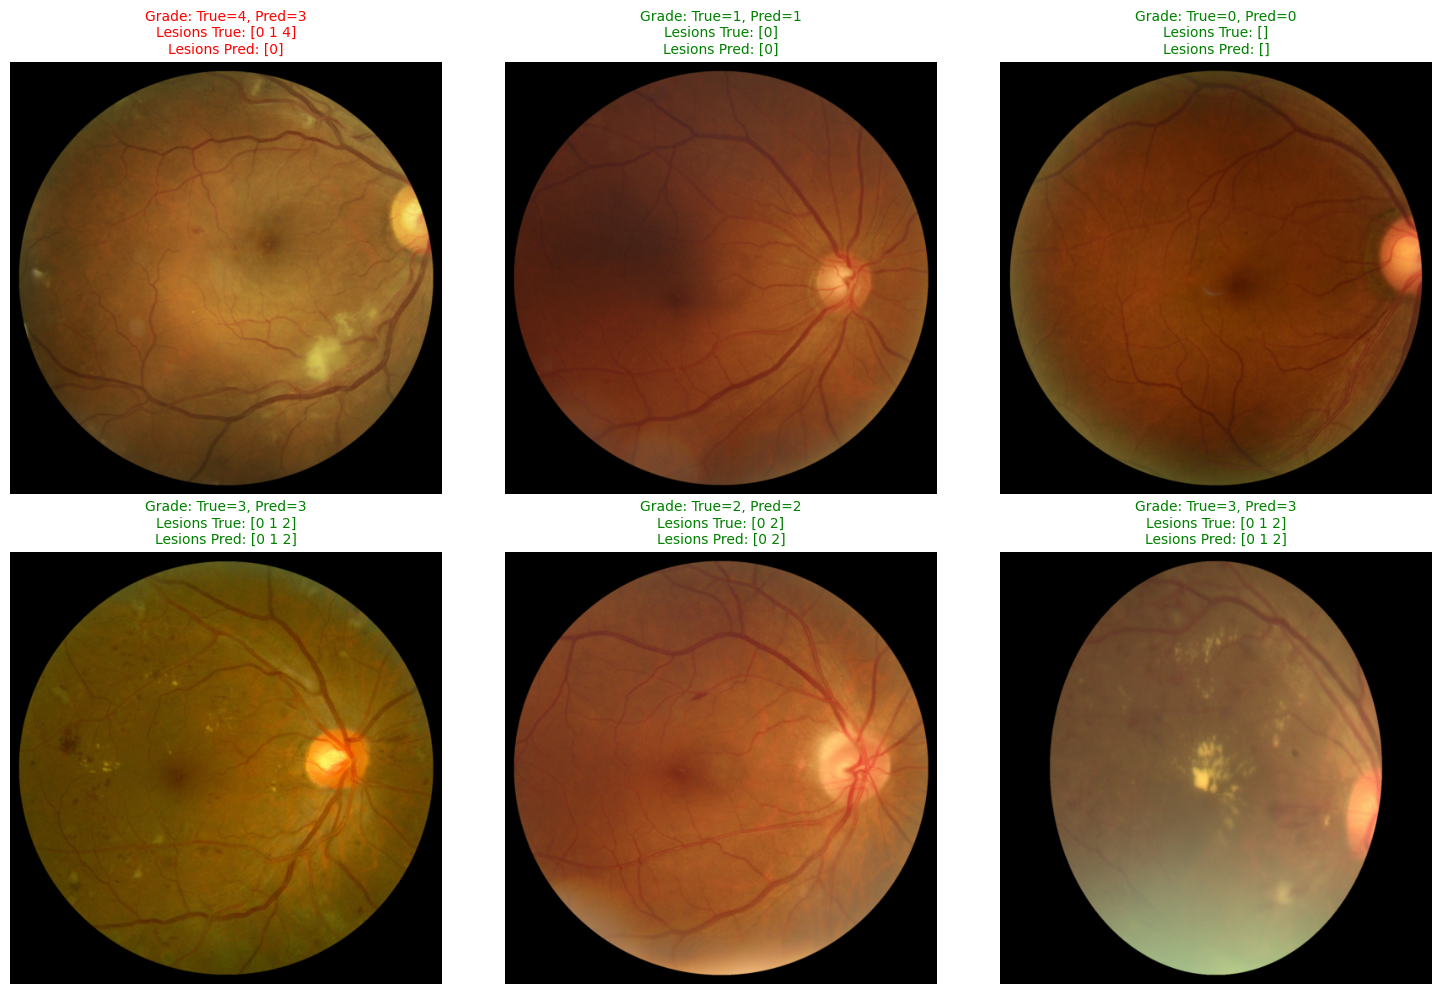

In [9]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Recreate the exact test_loader from your training script
data_dir = os.path.abspath("MMRDR")
modality = "cfp"
img_size = 512
batch_size = 12

_, test_df = execute_mmrdr_split(data_dir, modality)
img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_loader = DataLoader(
    MMRDRDataset(test_df, img_root, val_transform),
    batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)

# 3. Load your champion model
model = MultiScaleDRNet().to(device)
checkpoint = torch.load('best_multiscale_resnet.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# 4. Run the visualizer! (Make sure you ran the cell defining this function first)
visualize_predictions(model, test_loader, device)

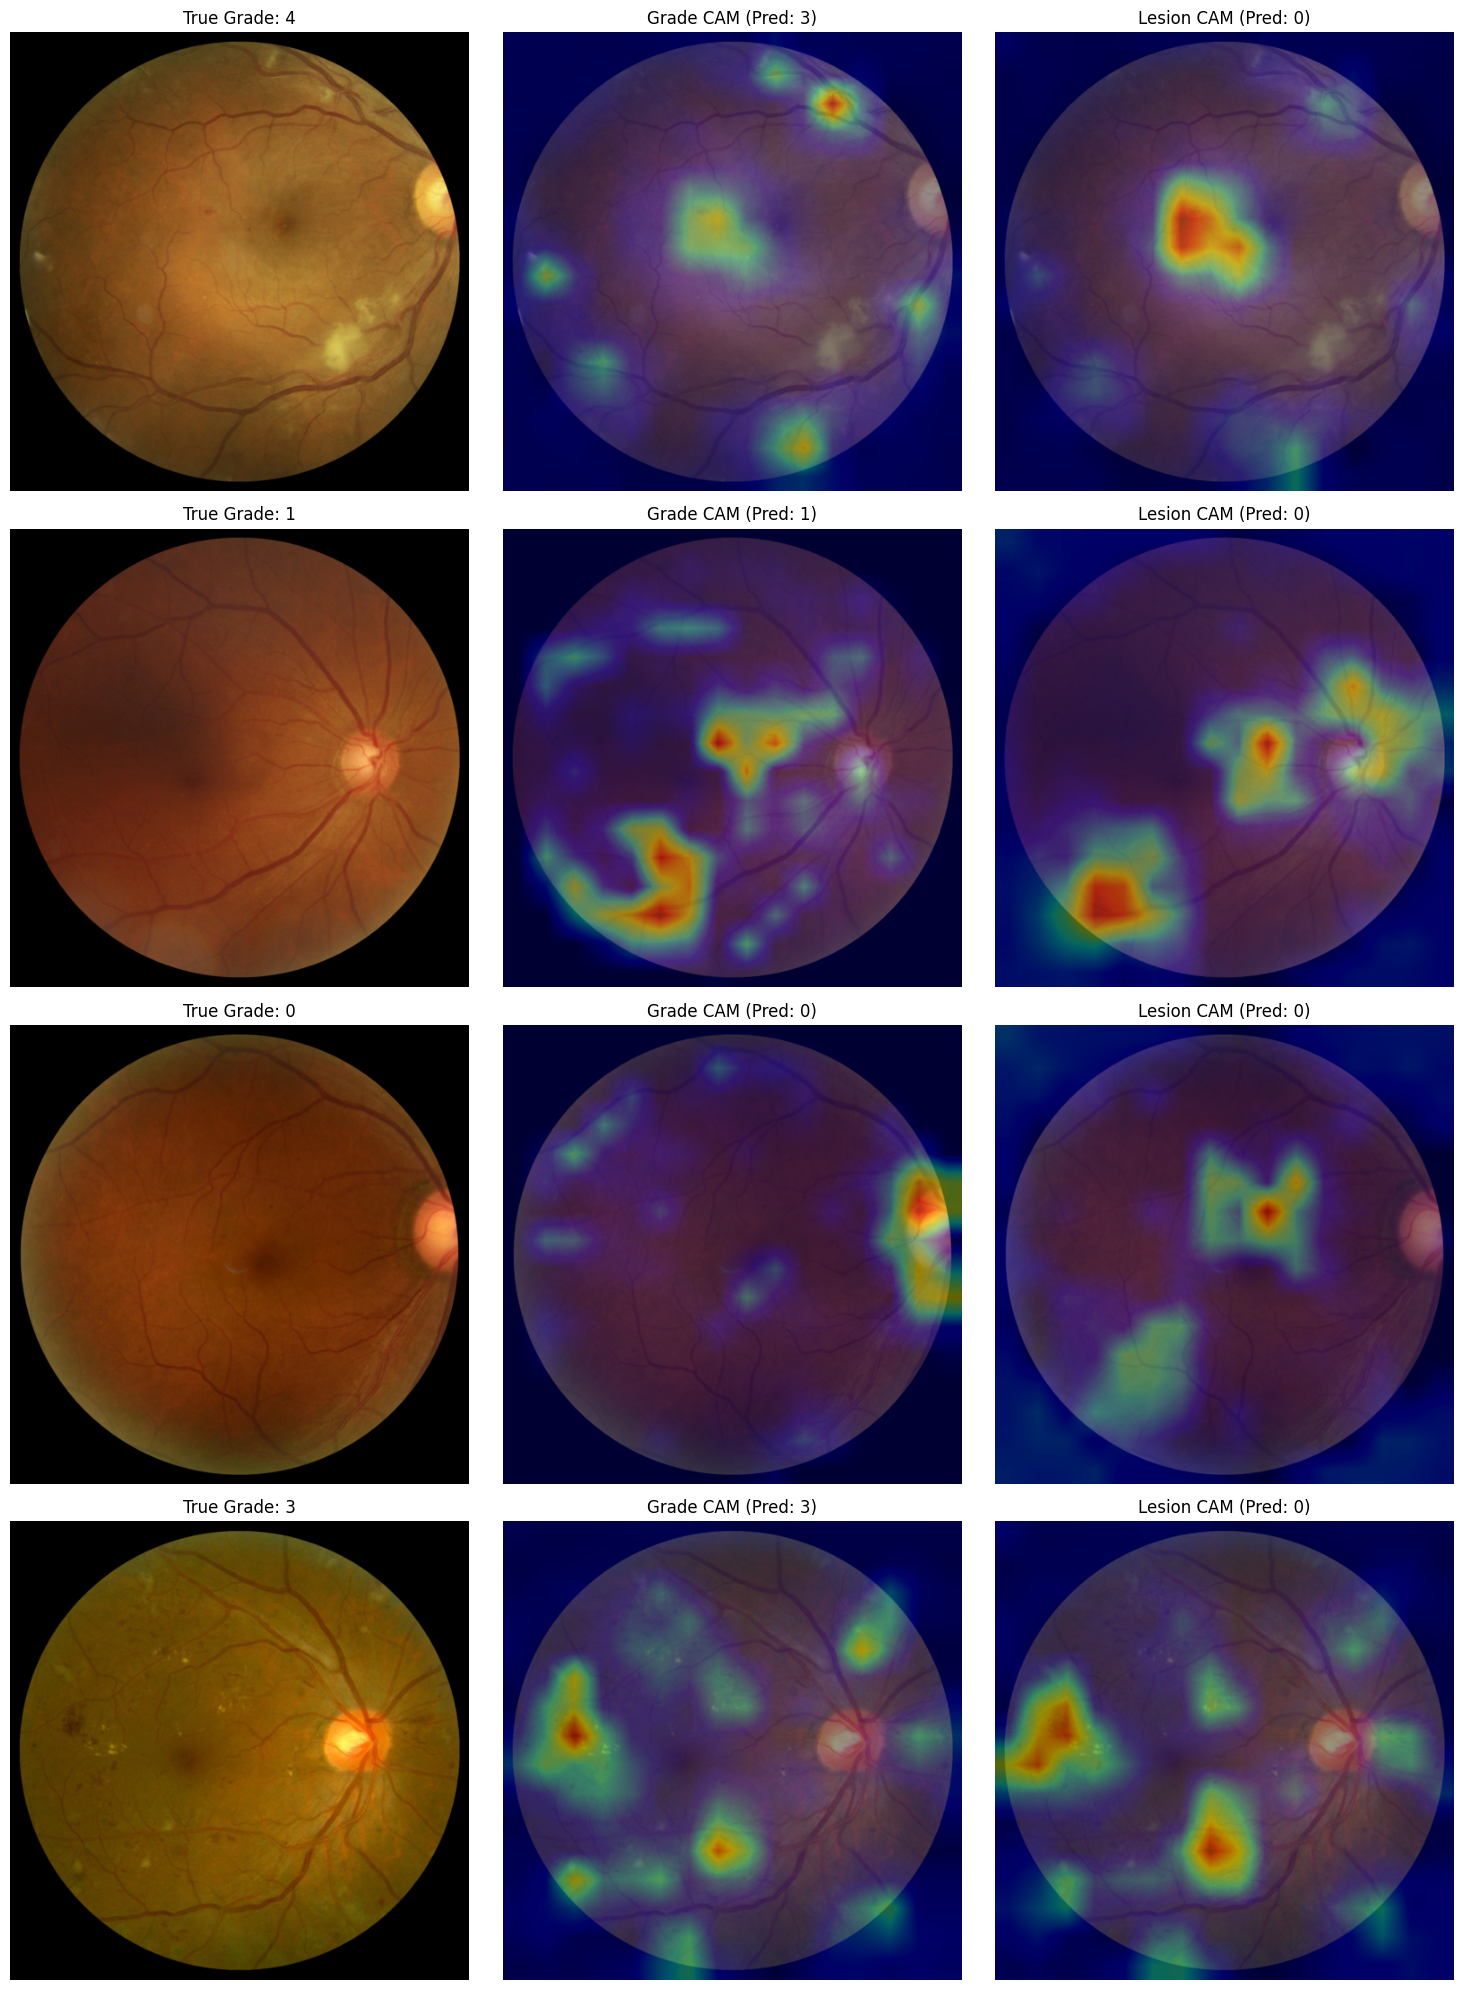

In [13]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2 

class CustomGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
        
    def generate(self, input_image, task='lesion', target_class=None):
        self.model.eval()
        self.model.zero_grad()
        
        grade_logits, lesion_logits = self.model(input_image)
        
        # Select which head we are visualizing
        logits = lesion_logits[0] if task == 'lesion' else grade_logits[0]
        
        if target_class is None:
            target_class = torch.argmax(logits).item()
            
        target = logits[target_class]
        target.backward(retain_graph=True) # retain_graph needed to backprop twice on same image
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0].clone() # Clone to avoid modifying the original during loop
        
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=0).squeeze()
        heatmap = F.relu(heatmap)
        if torch.max(heatmap) > 0:
            heatmap /= torch.max(heatmap)
            
        return heatmap.cpu().detach().numpy(), target_class

# ==========================================
# Batch Visualization Function
# ==========================================
def visualize_cam_batch(model, dataloader, device, num_images=4):
    cam = CustomGradCAM(model, model.layer4[-1])
    images, true_grades, true_lesions = next(iter(dataloader))
    
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    
    for i in range(min(num_images, len(images))):
        input_tensor = images[i].unsqueeze(0).to(device)
        
        # 1. Prepare Original Image
        orig_img = images[i].permute(1, 2, 0).numpy()
        orig_img = np.clip(std * orig_img + mean, 0, 1)
        
        # 2. Generate Grade Heatmap
        heat_g, class_g = cam.generate(input_tensor, task='grade')
        heat_g_res = cv2.resize(heat_g, (orig_img.shape[1], orig_img.shape[0]))
        heat_g_col = plt.cm.jet(heat_g_res)[:, :, :3]
        blend_g = np.clip(heat_g_col * 0.4 + orig_img * 0.6, 0, 1)
        
        # 3. Generate Lesion Heatmap
        heat_l, class_l = cam.generate(input_tensor, task='lesion')
        heat_l_res = cv2.resize(heat_l, (orig_img.shape[1], orig_img.shape[0]))
        heat_l_col = plt.cm.jet(heat_l_res)[:, :, :3]
        blend_l = np.clip(heat_l_col * 0.4 + orig_img * 0.6, 0, 1)
        
        # Plotting
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"True Grade: {true_grades[i].item()}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(blend_g)
        axes[i, 1].set_title(f"Grade CAM (Pred: {class_g})")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(blend_l)
        axes[i, 2].set_title(f"Lesion CAM (Pred: {class_l})")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run it!
visualize_cam_batch(model, test_loader, device, num_images=4)

In [ ]:
testing on similar dataset(just test)

interpretrability